In [3]:
# =====================================================================
# CELDA 1: GEMELO DIGITAL SOLAR (Fusión CENSALUD + NASA POWER)
# =====================================================================
import pandas as pd
import requests
import numpy as np

print("1. Cargando y consolidando archivos locales de CENSALUD...")

# Rutas de los archivos (ajustadas a la raíz de Colab)
ruta_2025 = "/content/7GT-UES_1-1-25_12-00_AM_1_Year_1779324630_v2.csv"
ruta_2026 = "/content/7GT-UES_1-1-26_12-00_AM_1_Year_1779324751_v2.csv"

# Leer archivos con 'latin-1' y low_memory=False para evitar DtypeWarnings
try:
    df_25 = pd.read_csv(ruta_2025, skiprows=5, encoding='latin-1', low_memory=False)
    df_26 = pd.read_csv(ruta_2026, skiprows=5, encoding='latin-1', low_memory=False)
    print("Archivos locales leídos correctamente.")
except FileNotFoundError as e:
    print(f"ERROR: {e}")
except Exception as e:
    print(f"ERROR INESPERADO: {e}")

# Unir ambos años
df_local = pd.concat([df_25, df_26], ignore_index=True)

# Formateo de fechas
df_local['Date & Time'] = pd.to_datetime(df_local['Date & Time'], errors='coerce')
df_local = df_local.dropna(subset=['Date & Time'])
df_local.set_index('Date & Time', inplace=True)

# Selección de las variables de ingeniería
columnas_utiles = {
    'Temp - °C': 'Local_Temp',
    'Hum - %': 'Local_Hum',
    'Avg Wind Speed - km/h': 'Local_WindSpeed',
    'Solar Rad - W/m^2': 'Local_SolarRad'  # Nuestro Target a predecir
}
df_local = df_local[list(columnas_utiles.keys())].rename(columns=columnas_utiles)

# Forzar formato numérico
for col in df_local.columns:
    df_local[col] = pd.to_numeric(df_local[col], errors='coerce')

# --- RESAMPLING (De 15 min a 1 Hora) ---
# Usamos 'h' minúscula para evitar el FutureWarning de Pandas
df_local_horario = df_local.resample('h').mean()
print(f"Rango de datos CENSALUD: {df_local_horario.index.min()} a {df_local_horario.index.max()}")

print("\n2. Conectando con la NASA para descargar clima satelital...")
lat, lon = 13.717910, -89.201804
fecha_ini = df_local_horario.index.min().strftime('%Y%m%d')
fecha_fin = df_local_horario.index.max().strftime('%Y%m%d')

# time-standard=LST asegura que el satélite use la hora de El Salvador
url_nasa = f"https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN,T2M,RH2M,CLOUD_AMT&community=RE&longitude={lon}&latitude={lat}&start={fecha_ini}&end={fecha_fin}&format=JSON&time-standard=LST"

resp = requests.get(url_nasa)
if resp.status_code == 200:
    datos_nasa = resp.json()['properties']['parameter']
    df_nasa = pd.DataFrame(datos_nasa)

    # Formatear el índice de la NASA a DateTime
    df_nasa.index = pd.to_datetime(df_nasa.index, format='%Y%m%d%H')

    # --- LA SOLUCIÓN AL ERROR ---
    # Usamos np.nan (Not a Number de Numpy) que es perfectamente compatible con astype(float)
    df_nasa = df_nasa.replace(-999.0, np.nan).astype(float)

    # --- EL MERGE ---
    # Unimos usando la hora exacta para tener el clima espacial y el local en la misma fila
    df_gemelo = pd.merge(df_local_horario, df_nasa, left_index=True, right_index=True, how='inner')
    df_gemelo = df_gemelo.dropna()

    print("\n¡FUSIÓN EXITOSA! Dataset Maestro del Gemelo Digital listo.")
    display(df_gemelo.head())
    print(f"Total de registros horarios útiles: {len(df_gemelo)}")
else:
    print(f"Error NASA: {resp.status_code}")


1. Cargando y consolidando archivos locales de CENSALUD...
Archivos locales leídos correctamente.


/tmp/ipykernel_3202/1194859937.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_local['Date & Time'] = pd.to_datetime(df_local['Date & Time'], errors='coerce')


Rango de datos CENSALUD: 2025-02-21 15:00:00 a 2026-05-20 18:00:00

2. Conectando con la NASA para descargar clima satelital...

¡FUSIÓN EXITOSA! Dataset Maestro del Gemelo Digital listo.


,Local_Temp,Local_Hum,Local_WindSpeed,Local_SolarRad,ALLSKY_SFC_SW_DWN,T2M,RH2M,CLOUD_AMT
2025-02-21 15:00:00,29.0,49.50,2.50,115.50,430.60,32.12,48.26,31.74
2025-02-21 16:00:00,29.0,50.00,5.25,120.25,228.85,31.27,50.72,37.26
2025-02-21 17:00:00,28.0,53.25,6.50,26.50,53.65,30.00,57.71,43.91
2025-02-21 18:00:00,26.0,60.00,9.50,1.00,0.00,28.89,64.12,41.73
2025-02-21 19:00:00,25.0,61.00,7.50,0.00,0.00,28.44,65.58,61.55


Total de registros horarios útiles: 7474


In [4]:
# =====================================================================
# CELDA 1.5: LA FUSIÓN TRIPLE (CENSALUD + NASA + OPEN-METEO)
# Objetivo: Añadir resolución de capas de nubes y luz difusa
# =====================================================================
import pandas as pd
import requests
import numpy as np

print("1. Conectando con la API de Open-Meteo (Modelos Europeos)...")

# Coordenadas de CENSALUD
lat, lon = 13.717910, -89.201804

# Formato de fechas para Open-Meteo (YYYY-MM-DD)
fecha_ini_om = df_local_horario.index.min().strftime('%Y-%m-%d')
fecha_fin_om = df_local_horario.index.max().strftime('%Y-%m-%d')

# URL de Open-Meteo (Historical API). Solicitamos capas de nubes y radiación difusa
url_om = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={fecha_ini_om}&end_date={fecha_fin_om}&hourly=cloudcover_low,cloudcover_mid,cloudcover_high,diffuse_radiation&timezone=America/El_Salvador"

try:
    resp_om = requests.get(url_om)
    if resp_om.status_code == 200:
        datos_om = resp_om.json()

        # Convertimos el JSON a DataFrame
        df_om = pd.DataFrame(datos_om['hourly'])

        # Formateamos el índice de tiempo
        df_om['time'] = pd.to_datetime(df_om['time'])
        df_om.set_index('time', inplace=True)

        print("Datos de Open-Meteo descargados con éxito.")

        # 2. LA FUSIÓN TRIPLE (Merge con df_gemelo existente)
        # Unimos el df_gemelo (CENSALUD + NASA) con df_om (Open-Meteo)
        df_maestro = pd.merge(df_gemelo, df_om, left_index=True, right_index=True, how='inner')
        df_maestro = df_maestro.dropna()

        print("\n¡FUSIÓN TRIPLE EXITOSA! Vista previa del nuevo Dataset de Alta Precisión:")
        display(df_maestro[['Local_SolarRad', 'CLOUD_AMT', 'cloudcover_low', 'cloudcover_high', 'diffuse_radiation']].head())
        print(f"\nTotal de registros horarios combinados: {len(df_maestro)}")

    else:
        print(f"Error en Open-Meteo (Código {resp_om.status_code}). Verifica las fechas del sensor.")
        # Si las fechas de 2026 de tu sensor chocan con la API histórica, nos avisará.
except Exception as e:
    print(f"Ocurrió un error en la conexión: {e}")

1. Conectando con la API de Open-Meteo (Modelos Europeos)...
Datos de Open-Meteo descargados con éxito.

¡FUSIÓN TRIPLE EXITOSA! Vista previa del nuevo Dataset de Alta Precisión:


,Local_SolarRad,CLOUD_AMT,cloudcover_low,cloudcover_high,diffuse_radiation
2025-02-21 15:00:00,115.50,31.74,1,0,131.0
2025-02-21 16:00:00,120.25,37.26,2,0,133.0
2025-02-21 17:00:00,26.50,43.91,0,0,78.0
2025-02-21 18:00:00,1.00,41.73,2,0,29.0
2025-02-21 19:00:00,0.00,61.55,4,0,0.0



Total de registros horarios combinados: 7474


1. Aplicando Filtro de Ciclo Solar (Eliminando la noche)...
Horas totales iniciales: 7474
Horas con Luz Útil (Dataset final para IA): 4048

2. Generando Gráfica: Efecto de la Nubosidad en la Generación Solar...


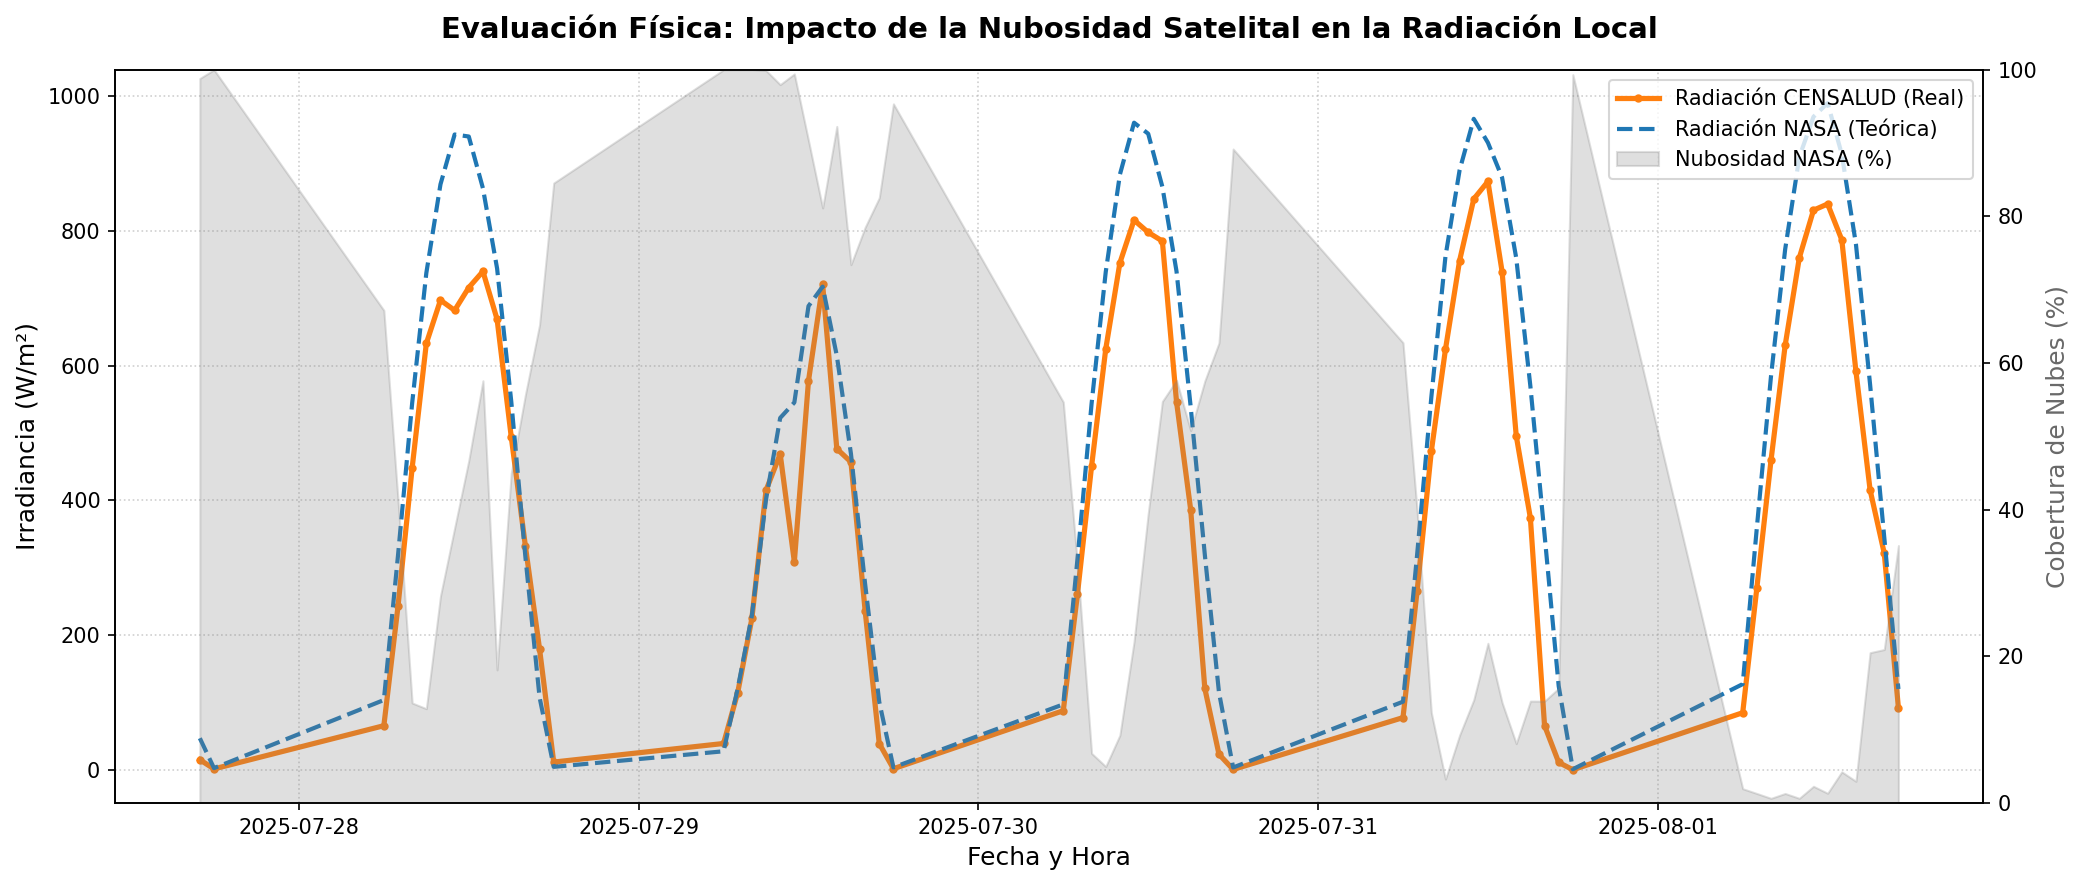


Gráfica guardada como 'analisis_nubes_radiacion.png'.


In [5]:
# =====================================================================
# CELDA 2: INGENIERÍA DE ATRIBUTOS (Filtro Nocturno) Y VISUALIZACIÓN
# =====================================================================
import matplotlib.pyplot as plt

print("1. Aplicando Filtro de Ciclo Solar (Eliminando la noche)...")

# Variables temporales para que la IA entienda la estacionalidad
df_gemelo['Hora'] = df_gemelo.index.hour
df_gemelo['Mes'] = df_gemelo.index.month

# Nos quedamos estrictamente con la ventana de generación (6 AM a 6 PM)
df_dia = df_gemelo[(df_gemelo['Hora'] >= 6) & (df_gemelo['Hora'] <= 18)].copy()

print(f"Horas totales iniciales: {len(df_gemelo)}")
print(f"Horas con Luz Útil (Dataset final para IA): {len(df_dia)}")

print("\n2. Generando Gráfica: Efecto de la Nubosidad en la Generación Solar...")

# Tomamos 5 días aleatorios a la mitad del dataset para visualizar el comportamiento
inicio_plot = df_dia.index[len(df_dia)//2]
fin_plot = inicio_plot + pd.Timedelta(days=5)
semana = df_dia[inicio_plot:fin_plot]

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=150)

# Radiación (Eje Y principal - Izquierdo)
ax1.plot(semana.index, semana['Local_SolarRad'], label='Radiación CENSALUD (Real)', color='#ff7f0e', linewidth=2.5, marker='.')
ax1.plot(semana.index, semana['ALLSKY_SFC_SW_DWN'], label='Radiación NASA (Teórica)', color='#1f77b4', linestyle='--', linewidth=2)
ax1.set_xlabel('Fecha y Hora', fontsize=12)
ax1.set_ylabel('Irradiancia (W/m²)', fontsize=12, color='black')
ax1.grid(True, linestyle=':', alpha=0.6)

# Nubosidad (Eje Y secundario - Derecho)
ax2 = ax1.twinx()
ax2.fill_between(semana.index, 0, semana['CLOUD_AMT'], color='gray', alpha=0.25, label='Nubosidad NASA (%)')
ax2.set_ylabel('Cobertura de Nubes (%)', fontsize=12, color='dimgray')
ax2.set_ylim(0, 100)

# Estética y Títulos
plt.title('Evaluación Física: Impacto de la Nubosidad Satelital en la Radiación Local', fontsize=14, fontweight='bold', pad=15)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('analisis_nubes_radiacion.png')
plt.show()

print("\nGráfica guardada como 'analisis_nubes_radiacion.png'.")


1. Preparando datos de Luz Útil para la Red Neuronal...
Hardware de entrenamiento: cpu
Secuencias creadas exitosamente. Lotes para entrenar: 100

3. Iniciando el Entrenamiento del Gemelo Digital...
Epoch 5/35 | Pérdida de Error (Loss): 0.2266
Epoch 10/35 | Pérdida de Error (Loss): 0.2043
Epoch 15/35 | Pérdida de Error (Loss): 0.1812
Epoch 20/35 | Pérdida de Error (Loss): 0.1513
Epoch 25/35 | Pérdida de Error (Loss): 0.1292
Epoch 30/35 | Pérdida de Error (Loss): 0.1084
Epoch 35/35 | Pérdida de Error (Loss): 0.0943


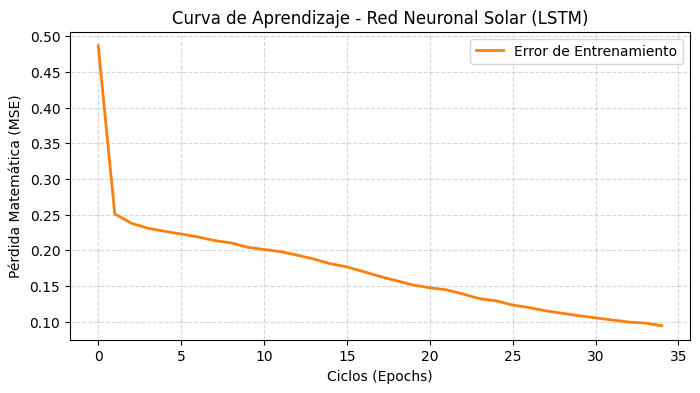

¡Entrenamiento finalizado con éxito!


In [6]:
# =====================================================================
# CELDA 3: ENTRENAMIENTO DEL MODELO PREDICTIVO SOLAR (LSTM)
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("1. Preparando datos de Luz Útil para la Red Neuronal...")

# Dispositivo de cálculo (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware de entrenamiento: {device}")

# Variables de entrada (Clima espacial, Clima local, Tiempo)
cols_features = ['Local_Temp', 'Local_Hum', 'CLOUD_AMT', 'ALLSKY_SFC_SW_DWN', 'Hora', 'Mes']
col_target = ['Local_SolarRad'] # Lo que la IA debe aprender a predecir

X = df_dia[cols_features].values
y = df_dia[col_target].values

# División cronológica: 80% Entrenar, 20% Probar el futuro
train_size = int(len(df_dia) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Escalamiento (Vital para que el LSTM maneje bien los W/m²)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

# --- CREACIÓN DE SECUENCIAS (Ventanas de Tiempo) ---
# 13 horas de luz útil por día (6 AM a 6 PM = 13 mediciones)
# Usaremos los últimos 3 días (39 horas) para predecir el próximo día (13 horas)
LOOKBACK = 39
HORIZON = 13

def create_sequences(X_data, y_data, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X_data) - lookback - horizon + 1):
        Xs.append(X_data[i:(i + lookback)])
        ys.append(y_data[(i + lookback):(i + lookback + horizon)])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = create_sequences(X_train_s, y_train_s, LOOKBACK, HORIZON)
X_te_seq, y_te_seq = create_sequences(X_test_s, y_test_s, LOOKBACK, HORIZON)

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq, dtype=torch.float32),
                                        torch.tensor(y_tr_seq, dtype=torch.float32)),
                          batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te_seq, dtype=torch.float32),
                                       torch.tensor(y_te_seq, dtype=torch.float32)),
                         batch_size=32, shuffle=False)

print(f"Secuencias creadas exitosamente. Lotes para entrenar: {len(train_loader)}")

# 2. ARQUITECTURA DE LA RED NEURONAL LSTM
class SolarLSTM(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, horizon):
        super(SolarLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.2)
        # La capa final emite 13 predicciones (todo el horizonte del día siguiente)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Solo usamos la información del último paso de la memoria
        return out.unsqueeze(2)      # Ajustamos forma geométrica del tensor

modelo_solar = SolarLSTM(n_features=len(cols_features), hidden_size=64, num_layers=2, horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_solar.parameters(), lr=0.001)

# 3. ENTRENAMIENTO
EPOCHS = 35
print("\n3. Iniciando el Entrenamiento del Gemelo Digital...")
train_losses = []

for epoch in range(EPOCHS):
    modelo_solar.train()
    batch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = modelo_solar(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()

        # Freno de gradientes para asegurar estabilidad
        torch.nn.utils.clip_grad_norm_(modelo_solar.parameters(), 1.0)
        optimizer.step()

        batch_loss += loss.item()

    train_losses.append(batch_loss / len(train_loader))

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Pérdida de Error (Loss): {train_losses[-1]:.4f}")

# Gráfica de Aprendizaje
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(train_losses, color='#ff7f0e', linewidth=2, label='Error de Entrenamiento')
plt.title('Curva de Aprendizaje - Red Neuronal Solar (LSTM)')
plt.xlabel('Ciclos (Epochs)')
plt.ylabel('Pérdida Matemática (MSE)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print("¡Entrenamiento finalizado con éxito!")


Evaluando el modelo en datos nunca antes vistos (Set de Prueba)...
Error Medio Absoluto (MAE) para este día: 110.78 W/m²


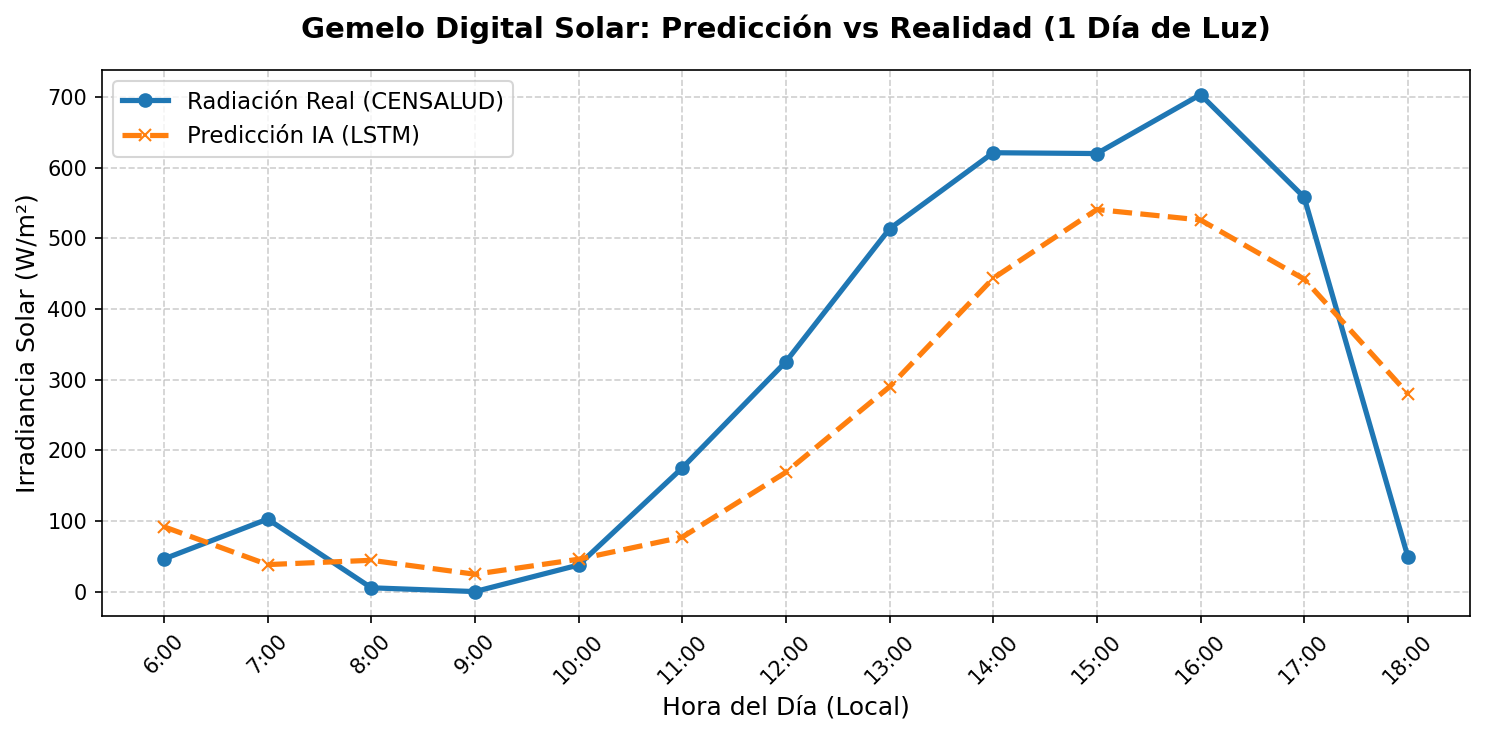


¡Pronóstico Generado! Gráfica guardada como 'prediccion_dia_solar.png'


In [7]:
# =====================================================================
# CELDA 4: VALIDACIÓN PREDICTIVA (Prediciendo el sol del mañana)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Evaluando el modelo en datos nunca antes vistos (Set de Prueba)...")

# 1. Poner el modelo en modo evaluación
modelo_solar.eval()

# Vamos a extraer una secuencia al azar del set de prueba (test_loader)
# para ver cómo el modelo predice un día completo (13 horas de luz)
X_muestra, y_muestra_real = next(iter(test_loader))

# Pasamos la muestra a la IA para que haga su predicción
with torch.no_grad():
    y_muestra_pred = modelo_solar(X_muestra.to(device)).cpu()

# 2. Desescalar los datos para volver a Watts por metro cuadrado (W/m²)
# Tomamos la primera secuencia del lote (índice 0)
real_scaled = y_muestra_real[0].numpy()
pred_scaled = y_muestra_pred[0].numpy()

real_wm2 = scaler_y.inverse_transform(real_scaled.reshape(-1, 1))
pred_wm2 = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))

# 3. Cálculo de Error (MAE)
mae = np.mean(np.abs(pred_wm2 - real_wm2))
print(f"Error Medio Absoluto (MAE) para este día: {mae:.2f} W/m²")

# 4. GRAFICANDO EL DÍA PREDICHO
plt.figure(figsize=(10, 5), dpi=150)

# El eje X serán las horas de luz útil (de 6 AM a 6 PM)
horas_dia = np.arange(6, 19)

plt.plot(horas_dia, real_wm2, label='Radiación Real (CENSALUD)', color='#1f77b4', marker='o', linewidth=2.5)
plt.plot(horas_dia, pred_wm2, label='Predicción IA (LSTM)', color='#ff7f0e', linestyle='--', marker='x', linewidth=2.5)

plt.title('Gemelo Digital Solar: Predicción vs Realidad (1 Día de Luz)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (Local)', fontsize=12)
plt.ylabel('Irradiancia Solar (W/m²)', fontsize=12)

# Formatear el eje X para que muestre horas claras
plt.xticks(horas_dia, [f"{h}:00" for h in horas_dia], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig('prediccion_dia_solar.png')
plt.show()

print("\n¡Pronóstico Generado! Gráfica guardada como 'prediccion_dia_solar.png'")


1. Integrando la Fusión Triple y Variables Astronómicas...

2. Entrenando Modelo V3 (Fusionando NASA + OpenMeteo + Local)..(ideal 75).
Epoch 15/75 completada.
Epoch 30/75 completada.
Epoch 45/75 completada.
Epoch 60/75 completada.
Epoch 75/75 completada.
¡Entrenamiento V3 finalizado!

---> Error MAE FINAL (Triple Fusión): 39.50 W/m² <---


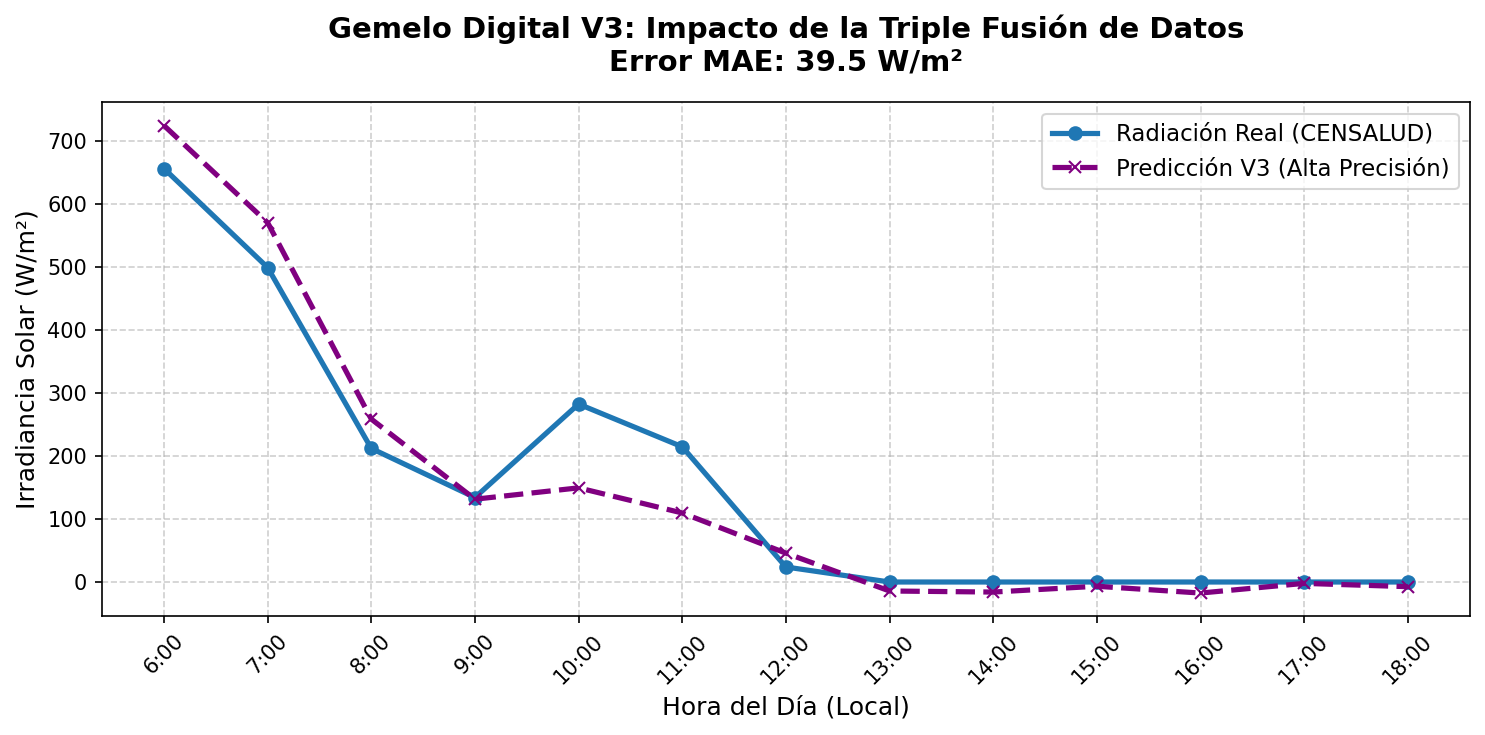

In [15]:
# =====================================================================
# CELDA 5 DEFINITIVA: MODELO SOLAR V3 (FUSIÓN TRIPLE DE DATOS)
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("1. Integrando la Fusión Triple y Variables Astronómicas...")

# Usamos el df_maestro que creamos en la Celda 1.5
df_v3 = df_maestro.copy()

# 1.1 Variables Astronómicas (El reloj del sol)
horas_span = 12
df_v3['Hora'] = df_v3.index.hour
df_v3['Mes'] = df_v3.index.month
df_v3['Hora_Sin'] = np.sin((df_v3['Hora'] - 6) * (2. * np.pi / horas_span))
df_v3['Hora_Cos'] = np.cos((df_v3['Hora'] - 6) * (2. * np.pi / horas_span))

# 1.2 EL NUEVO CEREBRO: Agregamos las nubes bajas, medias, altas y radiación difusa
cols_features_v3 = [
    'Local_Temp', 'Local_Hum',                  # Tierra (CENSALUD)
    'CLOUD_AMT', 'ALLSKY_SFC_SW_DWN',           # Espacio (NASA)
    'cloudcover_low', 'cloudcover_mid',         # Capas de Nubes (Open-Meteo)
    'cloudcover_high', 'diffuse_radiation',     # Luz Difusa (Open-Meteo)
    'Hora_Sin', 'Hora_Cos', 'Mes'               # Astronomía
]
col_target = ['Local_SolarRad']

X = df_v3[cols_features_v3].values
y = df_v3[col_target].values

# División 70/30
train_size = int(len(df_v3) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

# --- MEMORIA DEL MODELO ---
LOOKBACK = 65  # Mirar 5 días atrás
HORIZON = 13   # Predecir 1 día adelante

def create_sequences(X_data, y_data, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X_data) - lookback - horizon + 1):
        Xs.append(X_data[i:(i + lookback)])
        ys.append(y_data[(i + lookback):(i + lookback + horizon)])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = create_sequences(X_train_s, y_train_s, LOOKBACK, HORIZON)
X_te_seq, y_te_seq = create_sequences(X_test_s, y_test_s, LOOKBACK, HORIZON)

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq, dtype=torch.float32),
                                        torch.tensor(y_tr_seq, dtype=torch.float32)),
                          batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te_seq, dtype=torch.float32),
                                       torch.tensor(y_te_seq, dtype=torch.float32)),
                         batch_size=32, shuffle=False)

# 2. DEFINICIÓN DEL MODELO V3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SolarLSTMV3(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, horizon):
        super(SolarLSTMV3, self).__init__()
        # Ahora el modelo tiene 11 entradas (n_features) gracias a la triple fusión
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(2)

modelo_v3 = SolarLSTMV3(n_features=len(cols_features_v3), hidden_size=64, num_layers=2, horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_v3.parameters(), lr=0.0005)

# 3. ENTRENAMIENTO
EPOCHS = 75
print(f"\n2. Entrenando Modelo V3 (Fusionando NASA + OpenMeteo + Local)..(ideal 75).")

for epoch in range(EPOCHS):
    modelo_v3.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = modelo_v3(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_v3.parameters(), 1.0)
        optimizer.step()

    if (epoch+1) % 15 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} completada.")

print("¡Entrenamiento V3 finalizado!")

# 4. EVALUACIÓN DE LA TRIPLE FUSIÓN
modelo_v3.eval()
X_muestra, y_muestra_real = next(iter(test_loader))

with torch.no_grad():
    y_muestra_pred = modelo_v3(X_muestra.to(device)).cpu()

real_scaled = y_muestra_real[5].numpy()
pred_scaled = y_muestra_pred[5].numpy()

real_wm2 = scaler_y.inverse_transform(real_scaled.reshape(-1, 1))
pred_wm2 = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))

mae_v3 = np.mean(np.abs(pred_wm2 - real_wm2))
print(f"\n---> Error MAE FINAL (Triple Fusión): {mae_v3:.2f} W/m² <---")

# GRAFICANDO EL RESULTADO
plt.figure(figsize=(10, 5), dpi=150)
horas_dia = np.arange(6, 19)

plt.plot(horas_dia, real_wm2, label='Radiación Real (CENSALUD)', color='#1f77b4', marker='o', linewidth=2.5)
plt.plot(horas_dia, pred_wm2, label='Predicción V3 (Alta Precisión)', color='purple', linestyle='--', marker='x', linewidth=2.5)

plt.title(f'Gemelo Digital V3: Impacto de la Triple Fusión de Datos\nError MAE: {mae_v3:.1f} W/m²', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (Local)', fontsize=12)
plt.ylabel('Irradiancia Solar (W/m²)', fontsize=12)
plt.xticks(horas_dia, [f"{h}:00" for h in horas_dia], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

Calculando Generación Eléctrica Estimada con el Modelo de Alta Precisión...


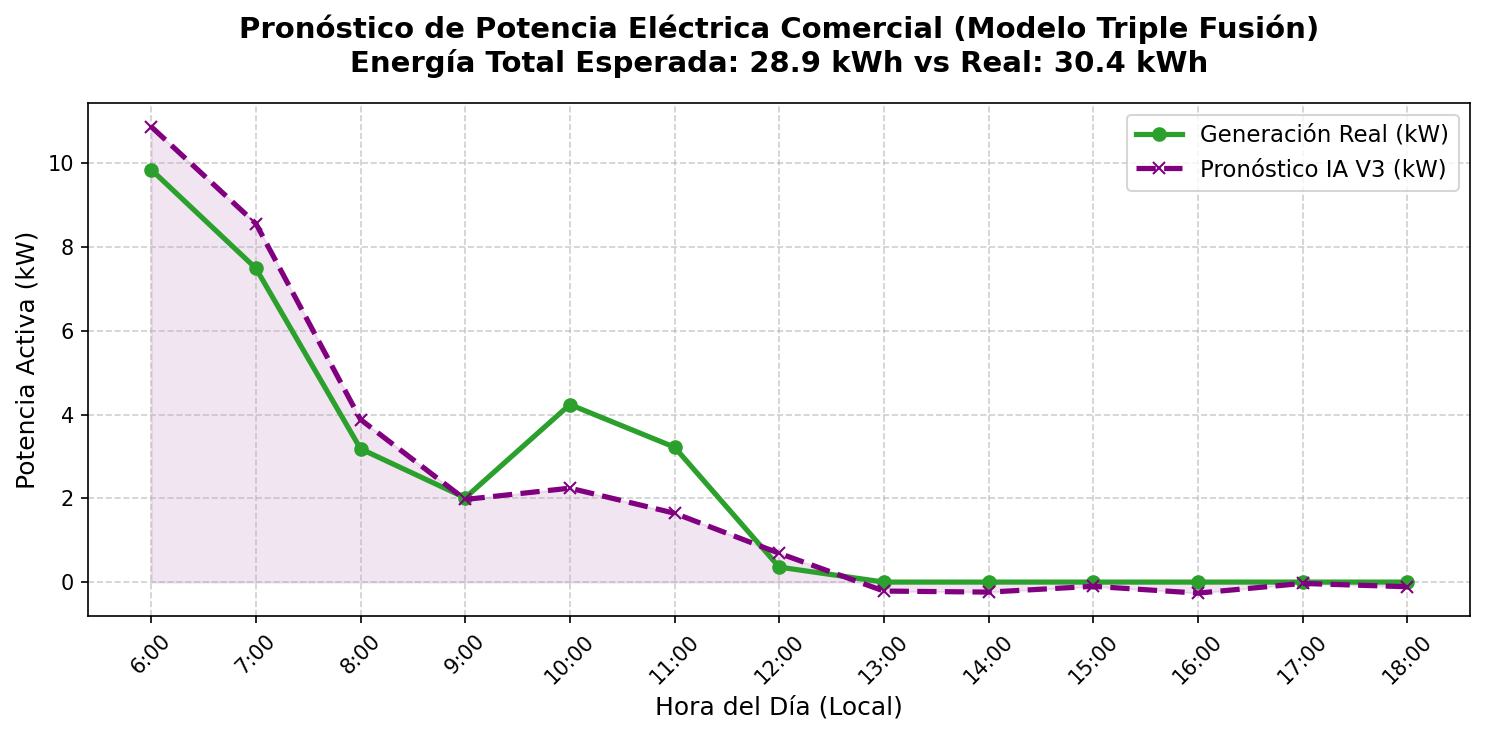


¡Cálculo eléctrico finalizado! Gráfica guardada como 'pronostico_potencia_final_v3.png'.


In [16]:
# =====================================================================
# CELDA 6: ESTIMACIÓN FINAL DE POTENCIA ELÉCTRICA (KW) CON MODELO V3
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Calculando Generación Eléctrica Estimada con el Modelo de Alta Precisión...")

# --- PARÁMETROS DE LA PLANTA SOLAR ESTÁNDAR ---
num_paneles = 50          # Cantidad de paneles
area_por_panel = 2.0      # Metros cuadrados por panel
area_total = num_paneles * area_por_panel
eficiencia_panel = 0.20   # 20% de eficiencia de conversión
performance_ratio = 0.75  # 75% de rendimiento real (descontando calor, polvo, etc.)

# Constante de conversión térmica a eléctrica
K_potencia = area_total * eficiencia_panel * performance_ratio

# Evaluación del modelo V3
modelo_v3.eval()
X_muestra, y_muestra_real = next(iter(test_loader))

# Elegimos el día 5 para la prueba (que sabemos que tiene nubosidad)
idx_dia = 5

with torch.no_grad():
    y_pred_scaled = modelo_v3(X_muestra[idx_dia:idx_dia+1].to(device)).cpu().numpy()[0]

real_scaled = y_muestra_real[idx_dia].numpy()

# Desescalamos a W/m2
irradiancia_real_wm2 = scaler_y.inverse_transform(real_scaled.reshape(-1, 1))
irradiancia_pred_wm2 = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# --- CONVERSIÓN FÍSICA (De W/m2 a kW) ---
potencia_real_kw = (irradiancia_real_wm2 * K_potencia) / 1000.0
potencia_pred_kw = (irradiancia_pred_wm2 * K_potencia) / 1000.0

# Cálculo de Energía Total (kWh) en todo el día (Área bajo la curva)
energia_total_real = np.sum(potencia_real_kw)
energia_total_pred = np.sum(potencia_pred_kw)

# --- GRÁFICA FINAL DE GENERACIÓN ELÉCTRICA ---
plt.figure(figsize=(10, 5), dpi=150)
horas_dia = np.arange(6, 19)

plt.plot(horas_dia, potencia_real_kw, label='Generación Real (kW)', color='#2ca02c', marker='o', linewidth=2.5)
plt.plot(horas_dia, potencia_pred_kw, label='Pronóstico IA V3 (kW)', color='purple', linestyle='--', marker='x', linewidth=2.5)

plt.title(f'Pronóstico de Potencia Eléctrica Comercial (Modelo Triple Fusión)\nEnergía Total Esperada: {energia_total_pred:.1f} kWh vs Real: {energia_total_real:.1f} kWh', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (Local)', fontsize=12)
plt.ylabel('Potencia Activa (kW)', fontsize=12)

# Sombreado bajo la curva para ilustrar visualmente la "Energía" generada
plt.fill_between(horas_dia, 0, potencia_pred_kw.flatten(), color='purple', alpha=0.1)

plt.xticks(horas_dia, [f"{h}:00" for h in horas_dia], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()

plt.savefig('pronostico_potencia_final_v3.png')
plt.show()

print("\n¡Cálculo eléctrico finalizado! Gráfica guardada como 'pronostico_potencia_final_v3.png'.")

Escaneando el futuro (Set de Prueba) para clasificar regímenes climáticos...


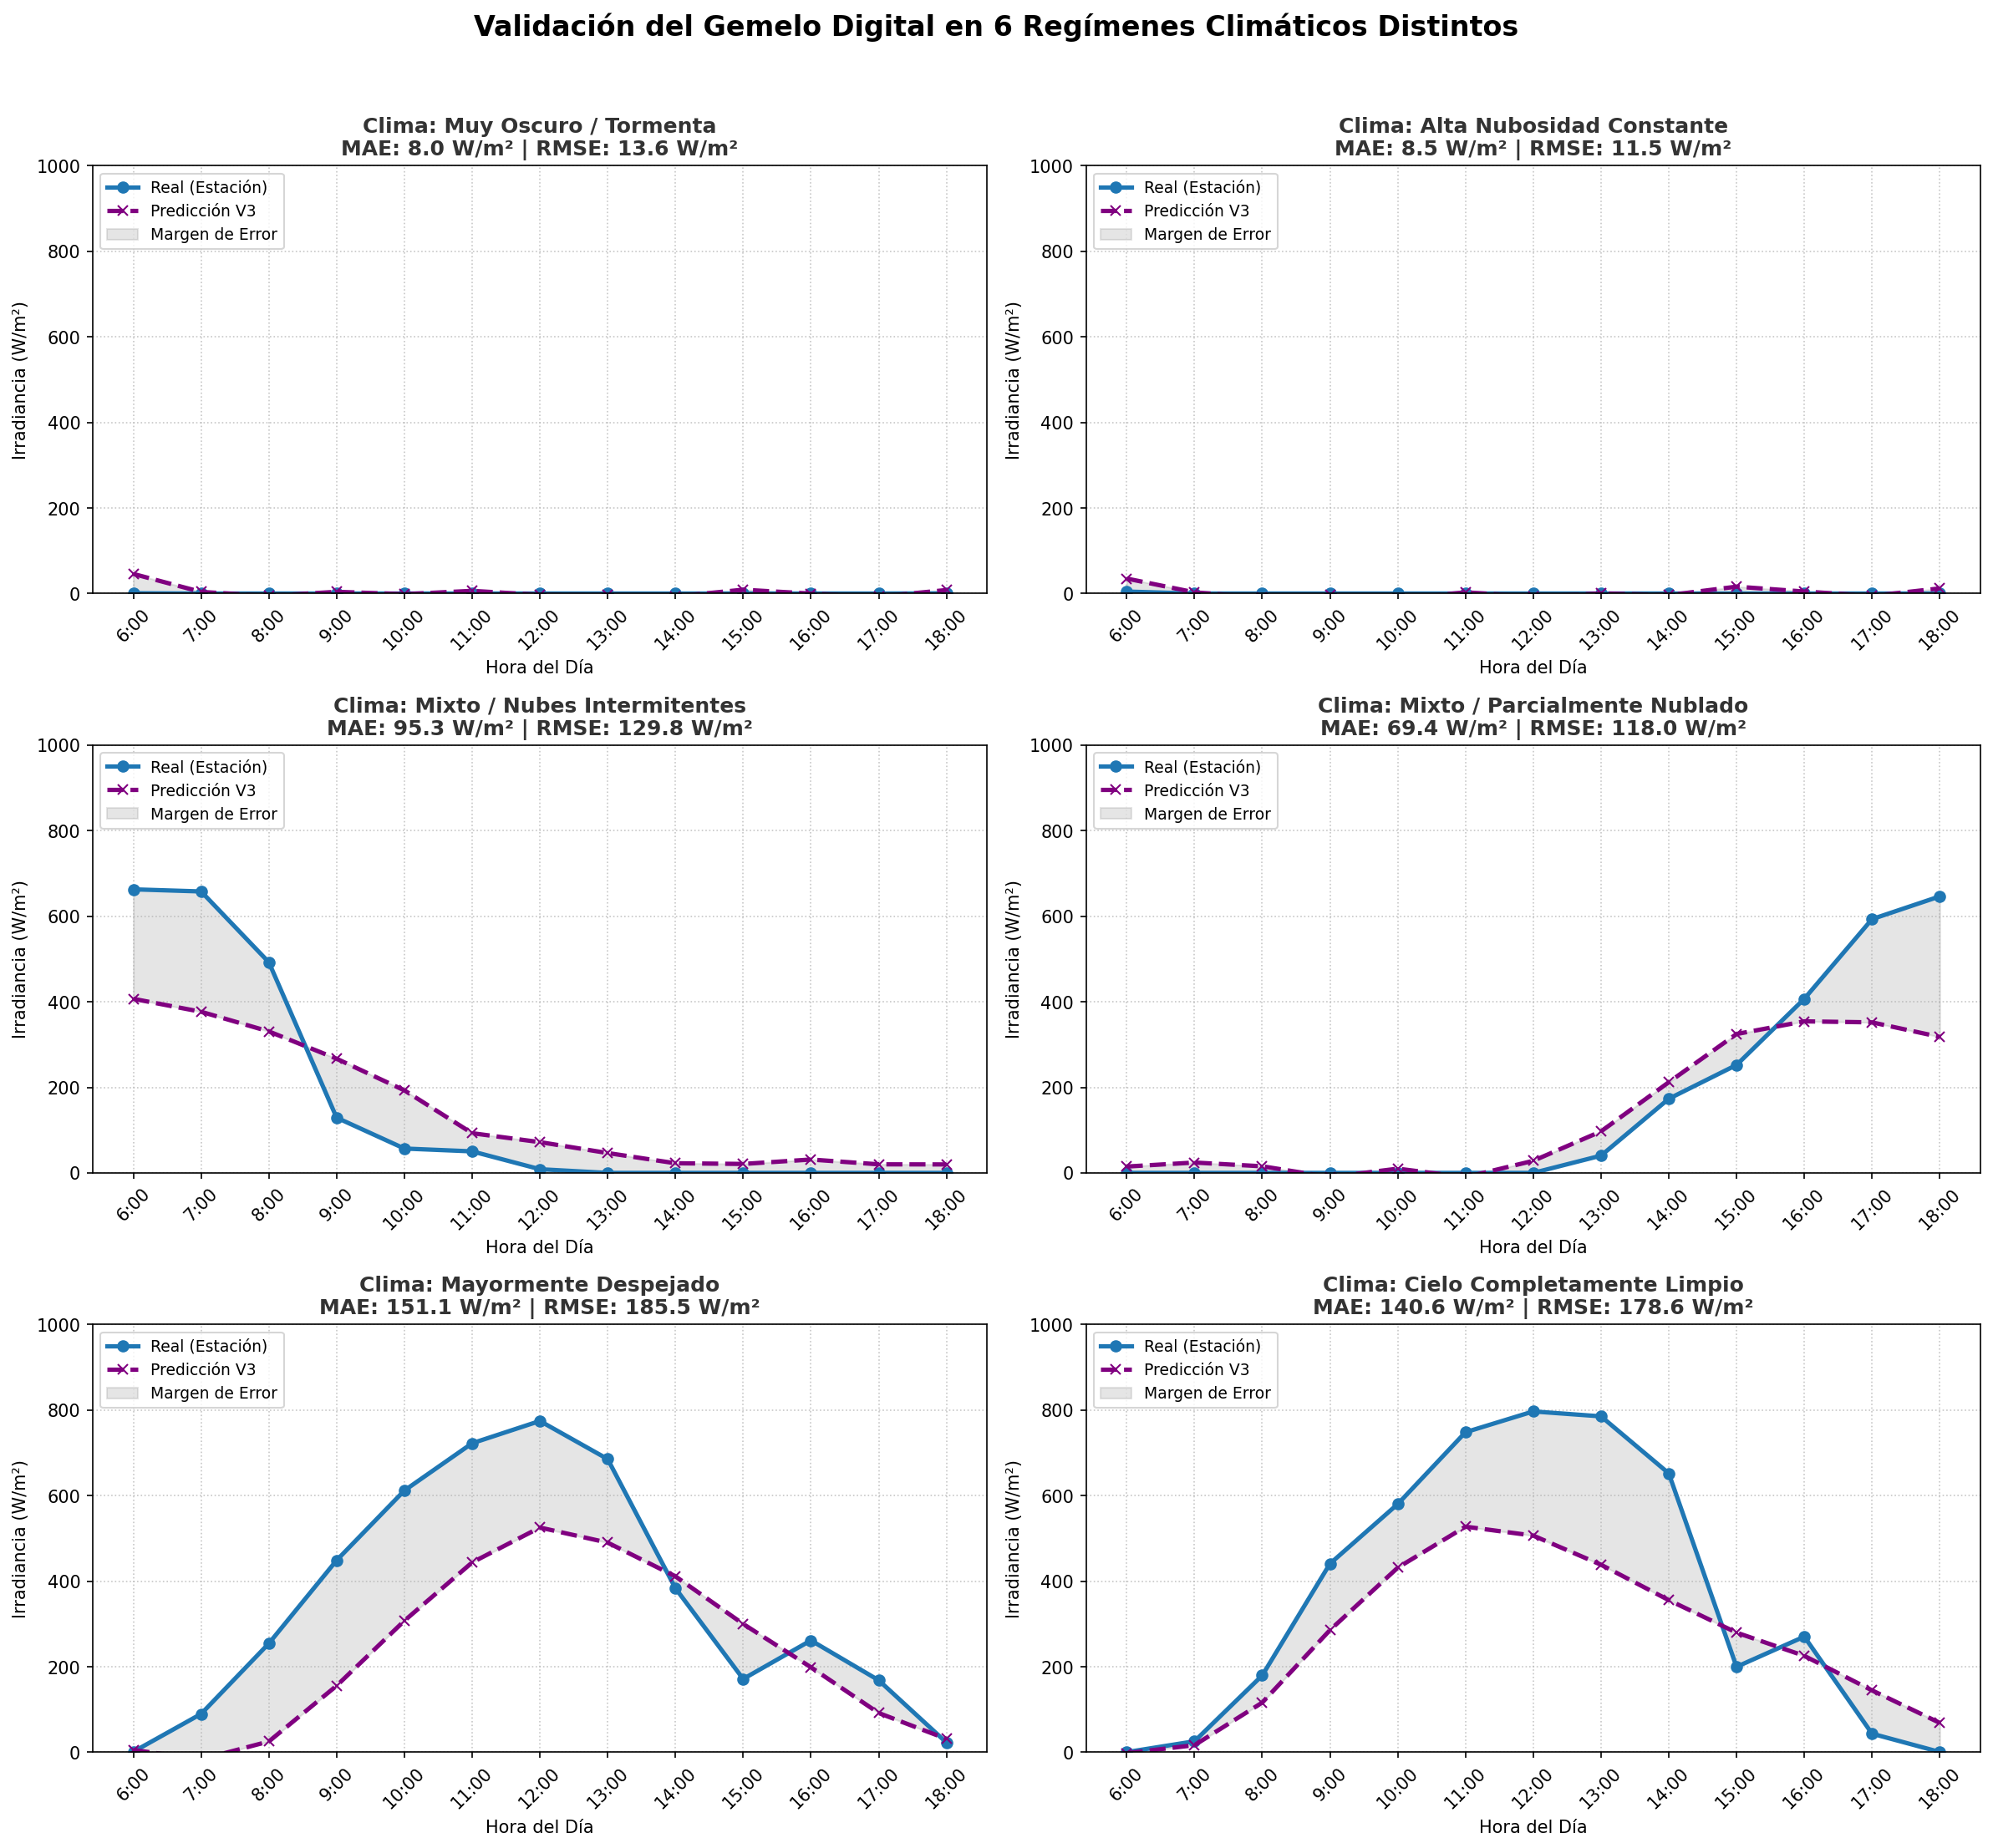


¡Panel de Auditoría Climática generado con éxito!


1. Ajustando datos a la regla 70/30 (Entrenamiento/Prueba)...
2. Re-entrenando el Cerebro con el nuevo ratio...
¡Entrenamiento 70/30 Finalizado!

3. Analizando Cielos Despejados y Calculando Métricas Científicas...


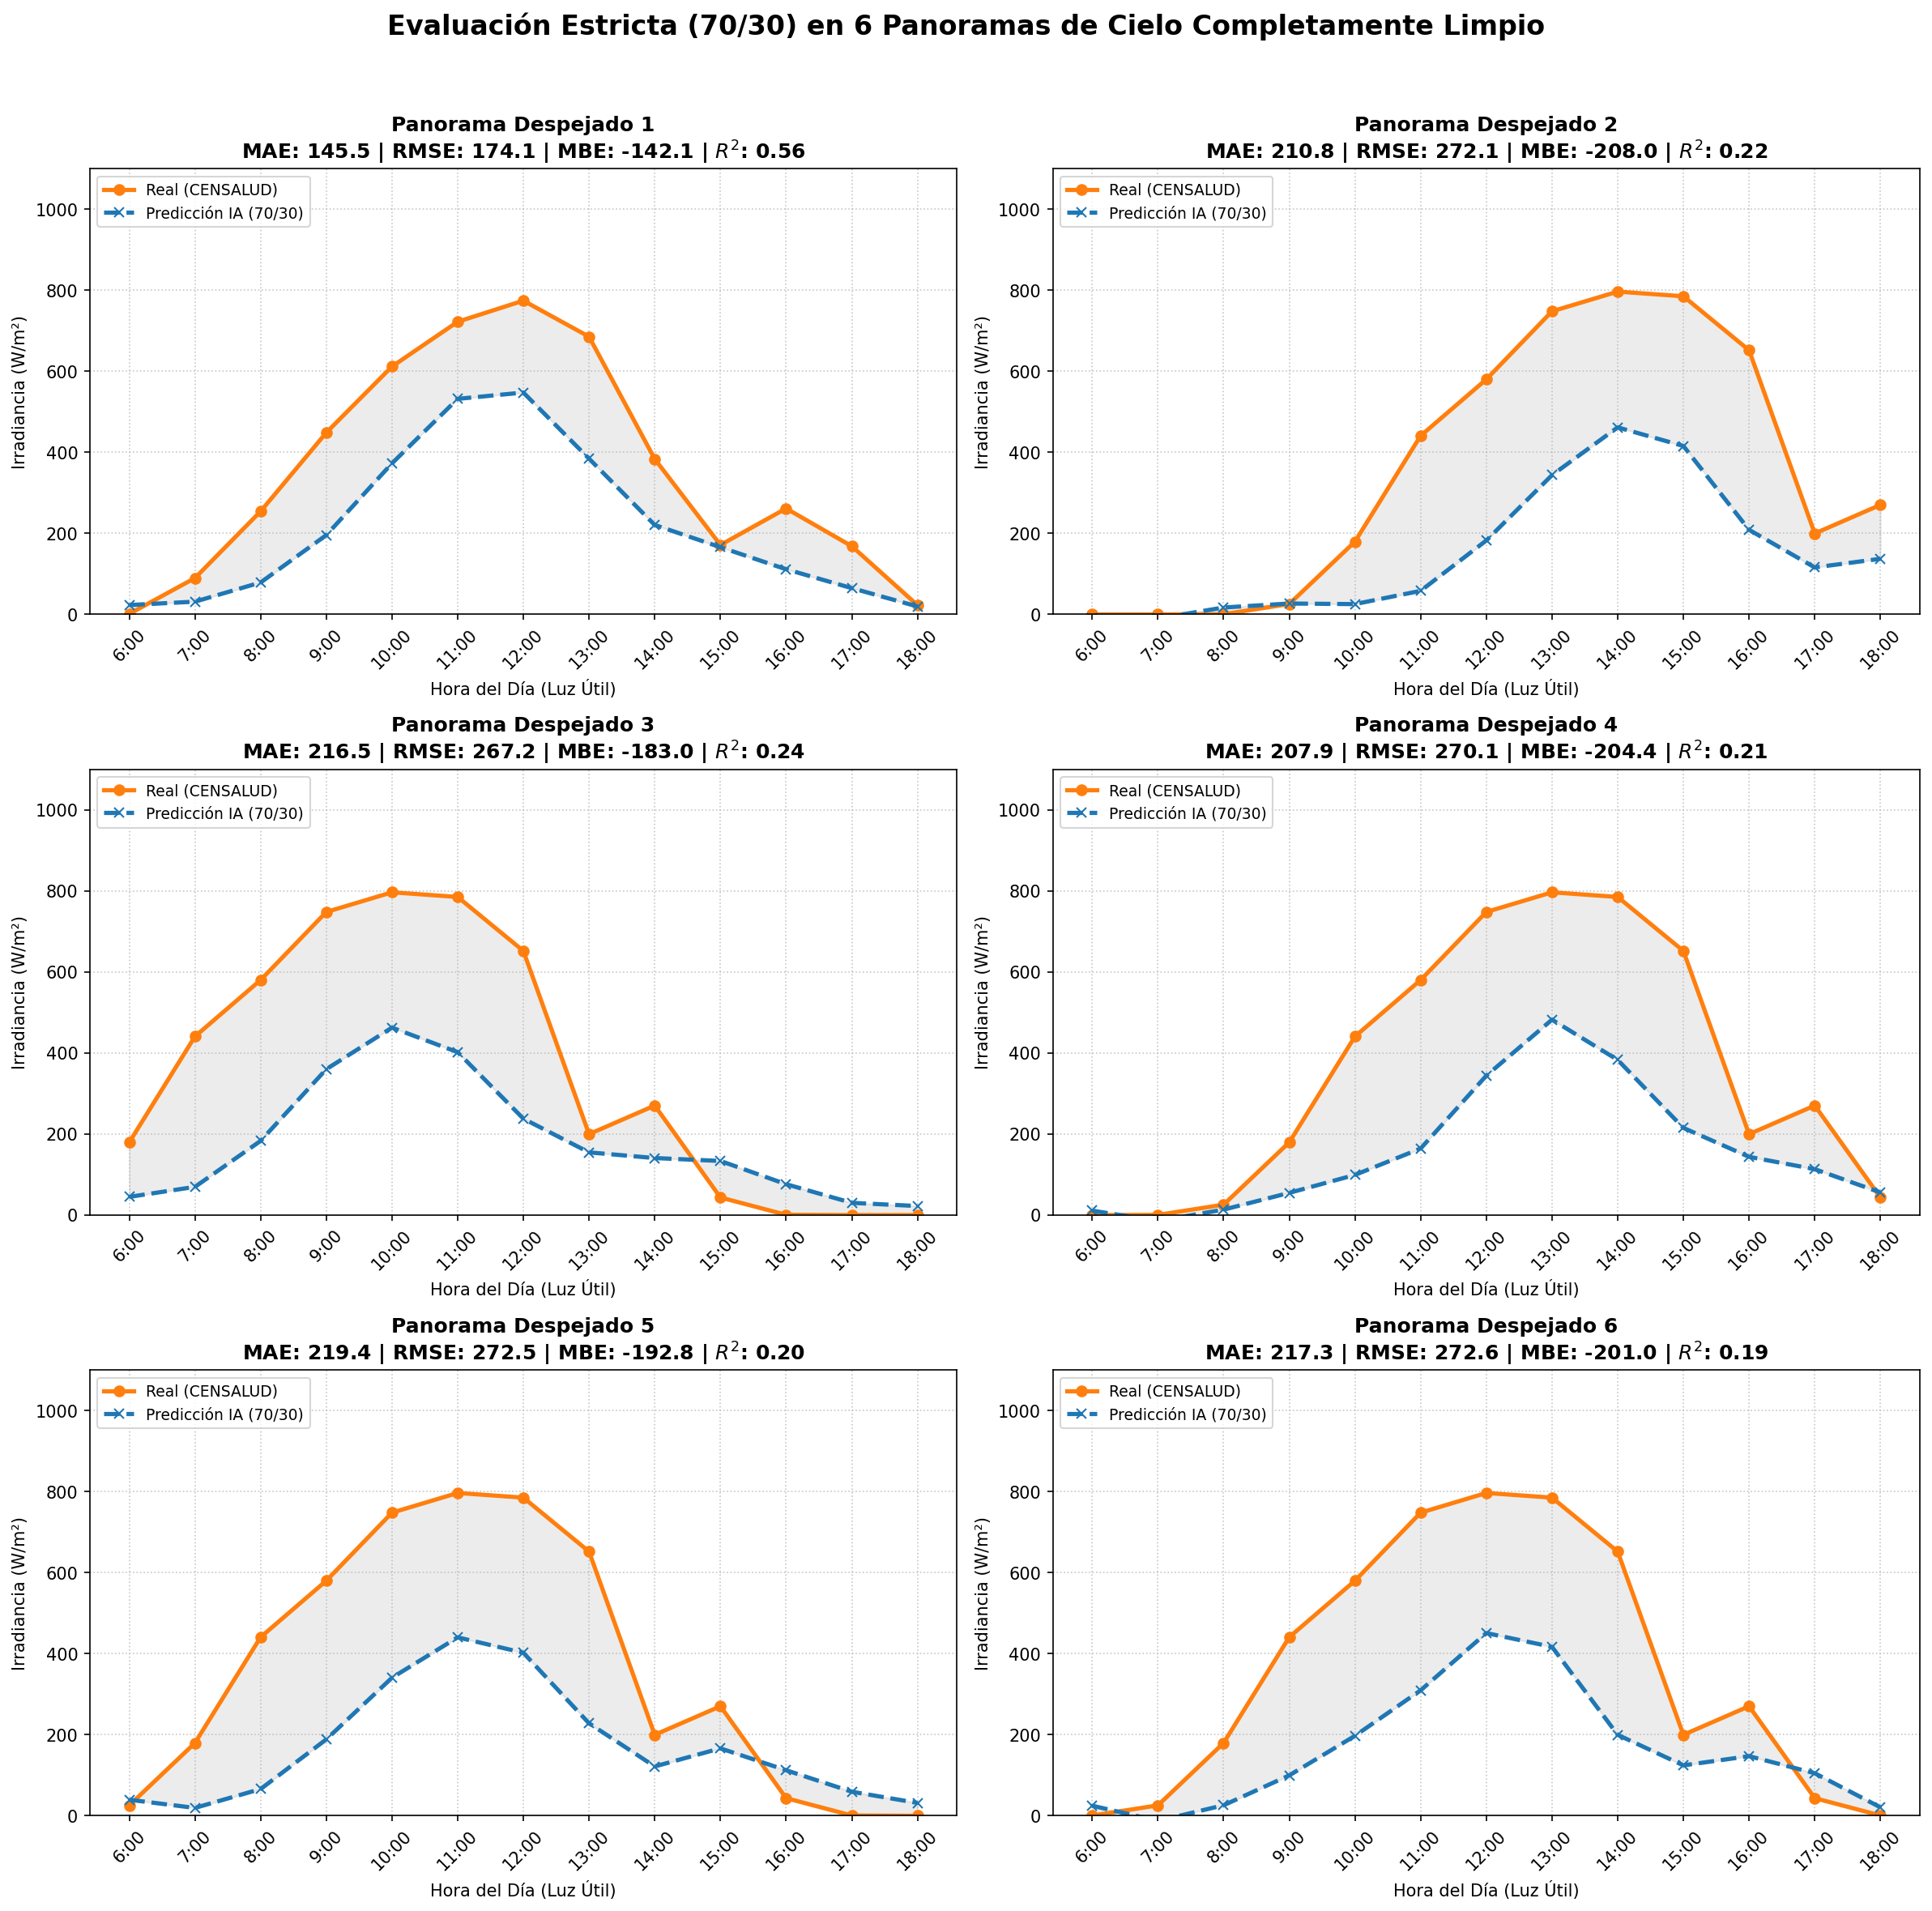


MÉTRICAS GLOBALES DEL MODELO (Set de Prueba 30%)
MAE (Error Medio Absoluto):      80.47 W/m²
RMSE (Error Cuadrático Medio):   143.40 W/m²
MBE (Sesgo Medio):               -15.27 W/m²
R² (Coef. de Determinación):     0.6396


In [17]:
# =====================================================================
# CELDA 8: RE-ENTRENAMIENTO (70/30) Y AUDITORÍA DE CIELOS DESPEJADOS
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score
from torch.utils.data import TensorDataset, DataLoader

print("1. Ajustando datos a la regla 70/30 (Entrenamiento/Prueba)...")

# --- 1. RE-DIVISIÓN 70/30 ---
train_size = int(len(df_v3) * 0.70) # <--- EL AJUSTE A 70%

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

X_tr_seq, y_tr_seq = create_sequences(X_train_s, y_train_s, LOOKBACK, HORIZON)
X_te_seq, y_te_seq = create_sequences(X_test_s, y_test_s, LOOKBACK, HORIZON)

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq, dtype=torch.float32),
                                        torch.tensor(y_tr_seq, dtype=torch.float32)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te_seq, dtype=torch.float32),
                                       torch.tensor(y_te_seq, dtype=torch.float32)), batch_size=32, shuffle=False)

# --- 2. RE-ENTRENAMIENTO DEL MODELO V3 (Más estricto) ---
print("2. Re-entrenando el Cerebro con el nuevo ratio...")
modelo_v3_7030 = SolarLSTMV3(n_features=len(cols_features_v3), hidden_size=64, num_layers=2, horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_v3_7030.parameters(), lr=0.0005)

EPOCHS = 75
for epoch in range(EPOCHS):
    modelo_v3_7030.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = modelo_v3_7030(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_v3_7030.parameters(), 1.0)
        optimizer.step()

print("¡Entrenamiento 70/30 Finalizado!\n")

# --- 3. EVALUACIÓN Y BÚSQUEDA DE CIELOS DESPEJADOS ---
print("3. Analizando Cielos Despejados y Calculando Métricas Científicas...")
modelo_v3_7030.eval()

todas_reales = []
todas_preds = []
energia_diaria = []

with torch.no_grad():
    for i in range(len(X_te_seq)):
        X_muestra = torch.tensor(X_te_seq[i:i+1], dtype=torch.float32).to(device)
        y_real_scaled = y_te_seq[i]
        y_pred_scaled = modelo_v3_7030(X_muestra).cpu().numpy()[0]

        y_real_wm2 = scaler_y.inverse_transform(y_real_scaled.reshape(-1, 1))
        y_pred_wm2 = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

        todas_reales.append(y_real_wm2)
        todas_preds.append(y_pred_wm2)
        energia_diaria.append(np.sum(y_real_wm2)) # Suma total de W/m2 del día

# Ordenamos los días de menor sol a mayor sol
energia_diaria = np.array(energia_diaria)
indices_ordenados = np.argsort(energia_diaria)

# Seleccionamos los 6 días con MÁS ENERGÍA (Los más despejados del 30% de pruebas)
idx_despejados = indices_ordenados[-6:]

# --- 4. GRAFICANDO LOS 6 PANORAMAS DESPEJADOS ---
fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=150)
axes = axes.flatten()
horas_dia = np.arange(6, 19)

for i, idx in enumerate(idx_despejados):
    ax = axes[i]
    real = todas_reales[idx].flatten()
    pred = todas_preds[idx].flatten()

    # CÁLCULO DE LAS 4 MÉTRICAS TEÓRICAS POR DÍA
    mae = np.mean(np.abs(pred - real))
    rmse = np.sqrt(np.mean((pred - real)**2))
    mbe = np.mean(pred - real)  # Si es negativo, el modelo subestimó el pico
    r2 = r2_score(real, pred)   # Qué tan perfecta es la forma de la campana

    ax.plot(horas_dia, real, label='Real (CENSALUD)', color='#ff7f0e', marker='o', linewidth=2.5)
    ax.plot(horas_dia, pred, label='Predicción IA (70/30)', color='#1f77b4', linestyle='--', marker='x', linewidth=2.5)
    ax.fill_between(horas_dia, real, pred, color='gray', alpha=0.15)

    # Estética de la sub-gráfica
    ax.set_title(f"Panorama Despejado {i+1}\nMAE: {mae:.1f} | RMSE: {rmse:.1f} | MBE: {mbe:.1f} | $R^2$: {r2:.2f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Hora del Día (Luz Útil)', fontsize=10)
    ax.set_ylabel('Irradiancia (W/m²)', fontsize=10)
    ax.set_xticks(horas_dia)
    ax.set_xticklabels([f"{h}:00" for h in horas_dia], rotation=45)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylim(0, max(1100, np.max(real) + 100))

plt.suptitle('Evaluación Estricta (70/30) en 6 Panoramas de Cielo Completamente Limpio', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('auditoria_cielos_limpios_7030.png')
plt.show()

# Cálculo Global de Métricas
todas_reales_flat = np.array(todas_reales).flatten()
todas_preds_flat = np.array(todas_preds).flatten()
mae_global = np.mean(np.abs(todas_preds_flat - todas_reales_flat))
rmse_global = np.sqrt(np.mean((todas_preds_flat - todas_reales_flat)**2))
mbe_global = np.mean(todas_preds_flat - todas_reales_flat)
r2_global = r2_score(todas_reales_flat, todas_preds_flat)

print("\n" + "="*50)
print("MÉTRICAS GLOBALES DEL MODELO (Set de Prueba 30%)")
print("="*50)
print(f"MAE (Error Medio Absoluto):      {mae_global:.2f} W/m²")
print(f"RMSE (Error Cuadrático Medio):   {rmse_global:.2f} W/m²")
print(f"MBE (Sesgo Medio):               {mbe_global:.2f} W/m²")
print(f"R² (Coef. de Determinación):     {r2_global:.4f}")
print("="*50)

1. Preparando datos con MinMaxScaler (Rango 0 a 1) y división 70/30...
2. Entrenando Red Neuronal Expandida (128 neuronas)...
¡Entrenamiento Finalizado!

3. Auditando el modelo en 6 Regímenes Climáticos (Lluvia, Mixto, Despejado)...


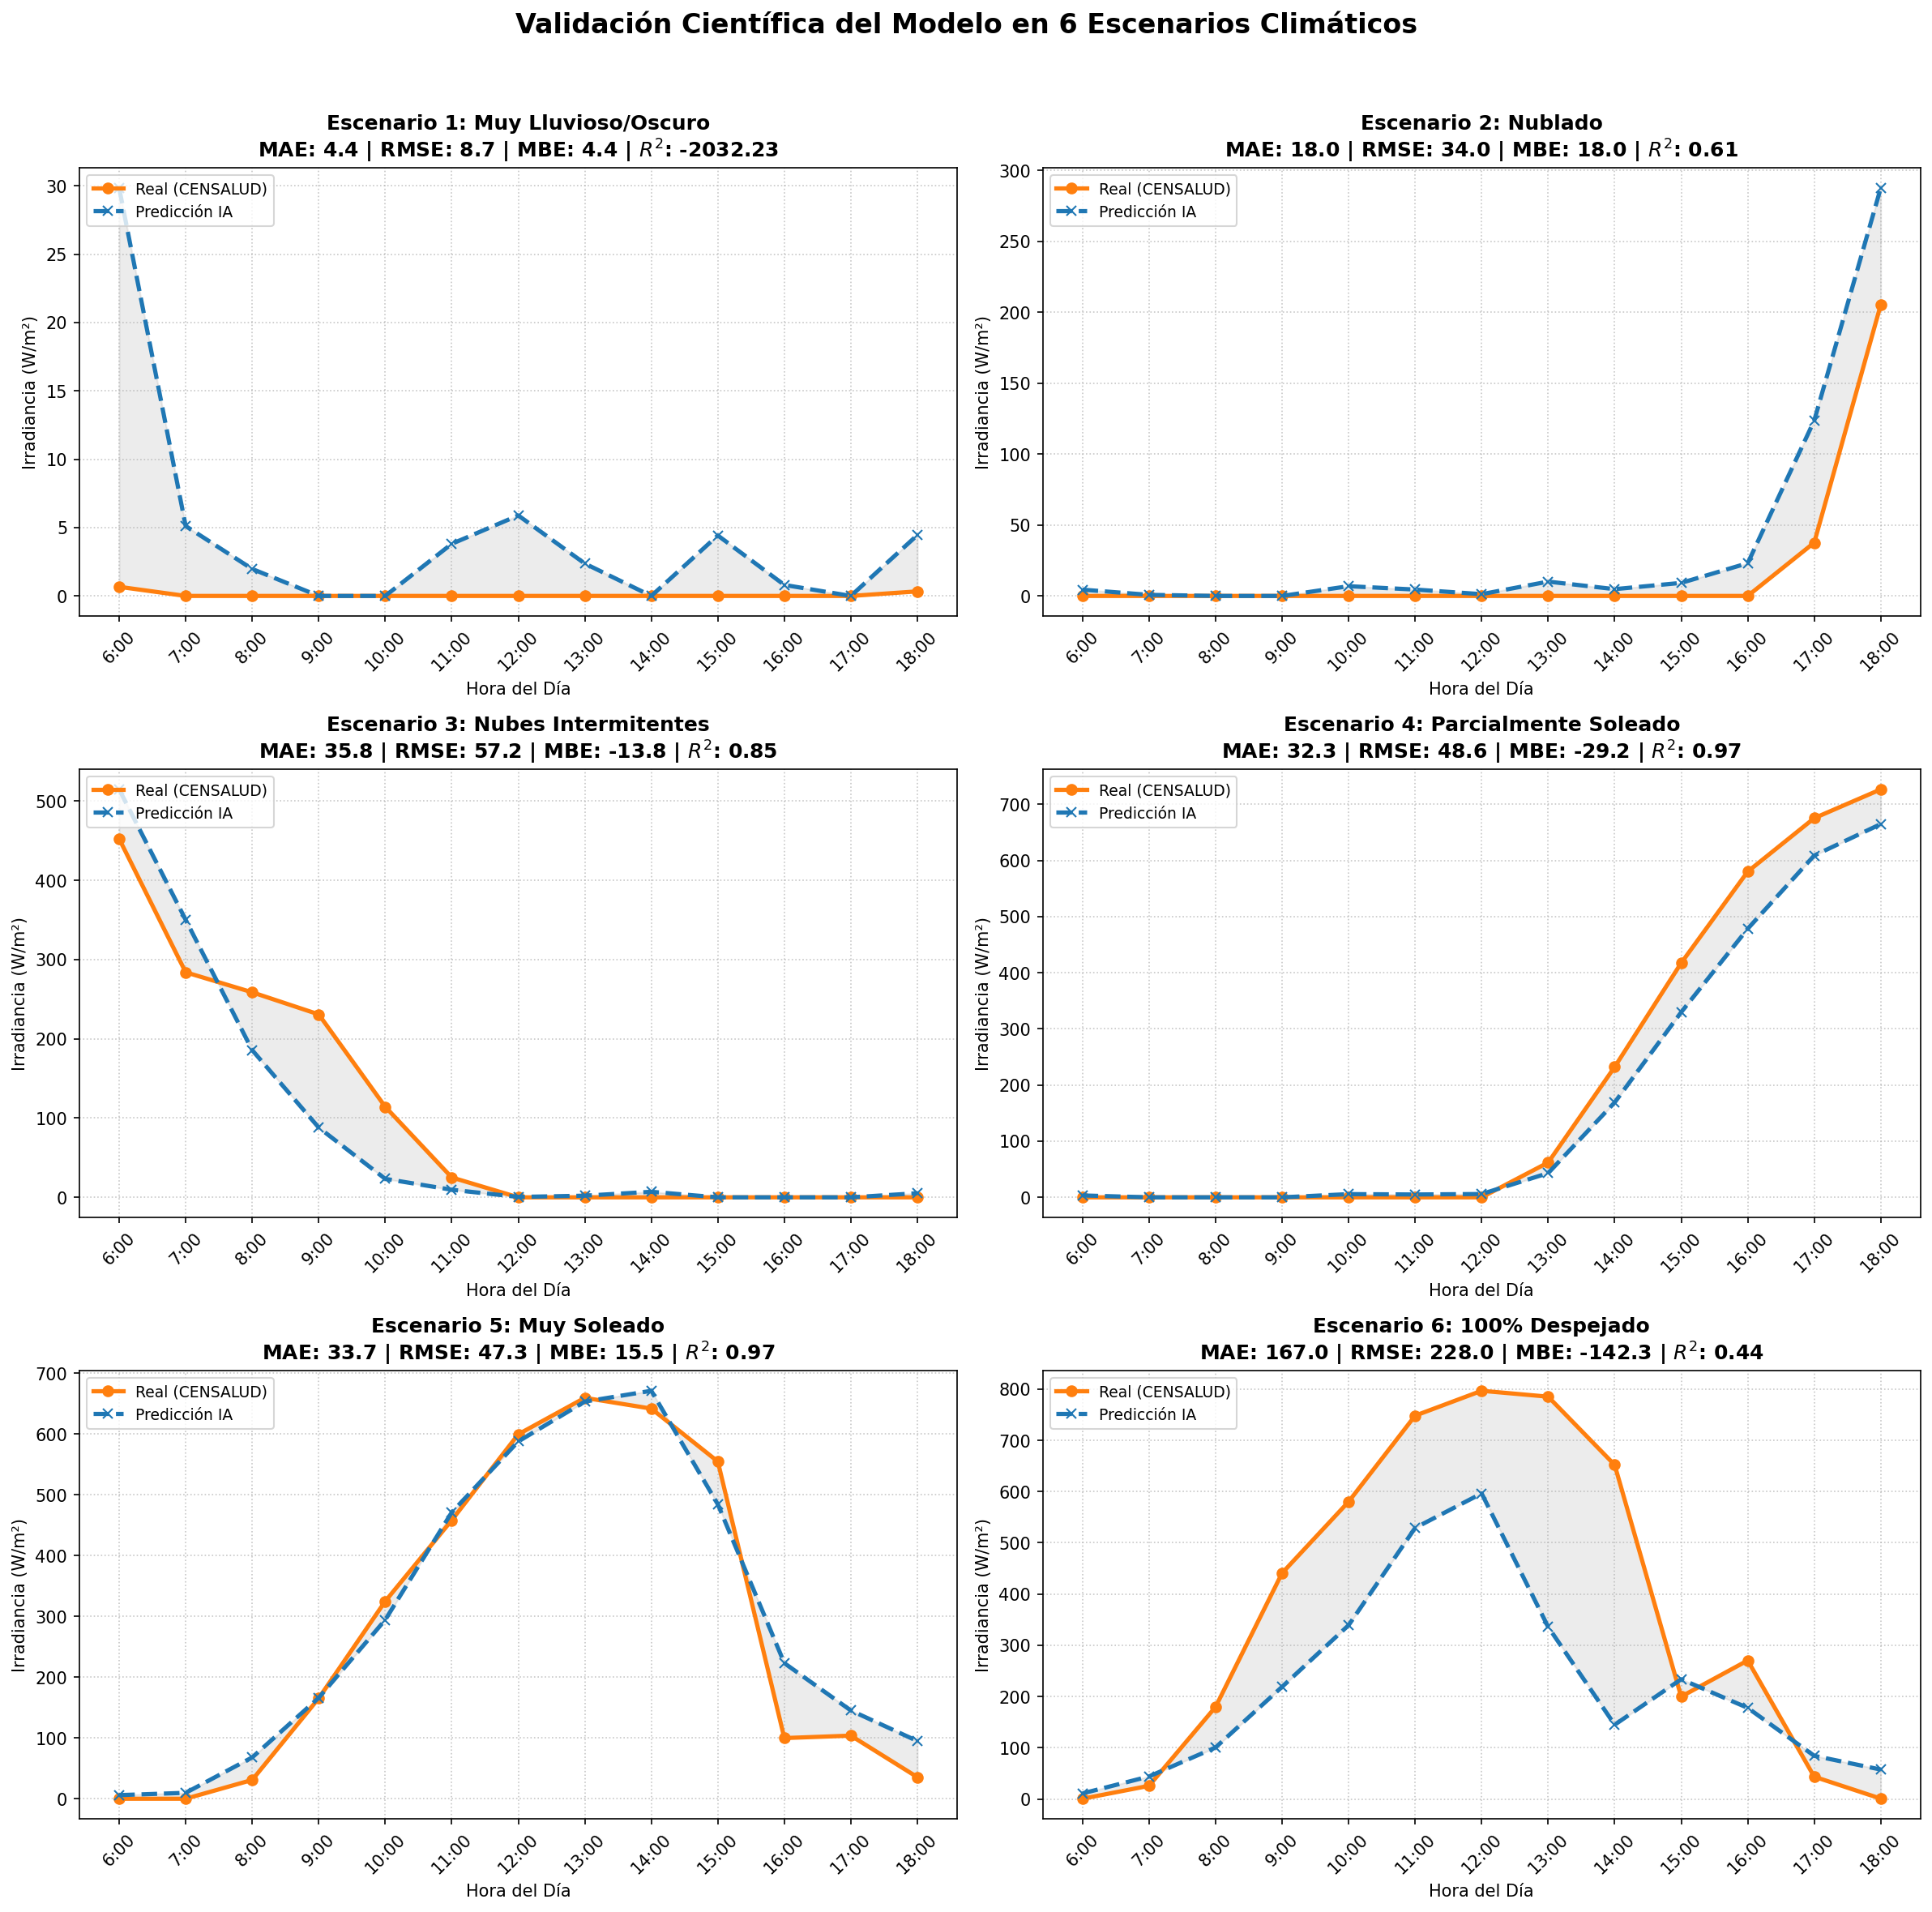


MÉTRICAS GLOBALES FINALES (Set de Prueba 30%)
MAE (Error Medio Absoluto):      68.47 W/m²
RMSE (Error Cuadrático Medio):   126.27 W/m²
MBE (Sesgo Medio):               36.29 W/m²
R² (Coef. de Determinación):     0.7206


In [14]:
# =====================================================================
# CELDA 10: MODELO FINAL (70/30) - SOLUCIÓN A LA ATENUACIÓN DE PICOS
# Objetivo: Romper la barrera de los 550 W/m2 usando MinMaxScaler y 128 neuronas.
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler # <--- EL CAMBIO CLAVE
from torch.utils.data import TensorDataset, DataLoader

print("1. Preparando datos con MinMaxScaler (Rango 0 a 1) y división 70/30...")

# Extraemos features y target de nuestro df_v3 (que ya tiene Triple Fusión y Filtro Nocturno)
X = df_v3[cols_features_v3].values
y = df_v3[['Local_SolarRad']].values

# División 70/30 Estricta
train_size = int(len(df_v3) * 0.70)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Usamos MinMaxScaler para no "aplastar" los picos
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

# Creamos las secuencias (Lookback 65h, Horizon 13h)
X_tr_seq, y_tr_seq = create_sequences(X_train_s, y_train_s, LOOKBACK, HORIZON)
X_te_seq, y_te_seq = create_sequences(X_test_s, y_test_s, LOOKBACK, HORIZON)

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq, dtype=torch.float32),
                                        torch.tensor(y_tr_seq, dtype=torch.float32)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te_seq, dtype=torch.float32),
                                       torch.tensor(y_te_seq, dtype=torch.float32)), batch_size=32, shuffle=False)

# --- 2. EL NUEVO CEREBRO (128 Neuronas) ---
print("2. Entrenando Red Neuronal Expandida (128 neuronas)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SolarLSTM_Final(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, horizon):
        super(SolarLSTM_Final, self).__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(2)

#  128
modelo_final = SolarLSTM_Final(n_features=len(cols_features_v3), hidden_size=128, num_layers=2, horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelo_final.parameters(), lr=0.0005)

EPOCHS = 75
for epoch in range(EPOCHS):
    modelo_final.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = modelo_final(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_final.parameters(), 1.0)
        optimizer.step()

print("¡Entrenamiento Finalizado!\n")

# --- 3. EVALUACIÓN DE 6 PANORAMAS CLIMÁTICOS DISTINTOS ---
print("3. Auditando el modelo en 6 Regímenes Climáticos (Lluvia, Mixto, Despejado)...")
modelo_final.eval()

todas_reales = []
todas_preds = []
energia_diaria = []

with torch.no_grad():
    for i in range(len(X_te_seq)):
        X_muestra = torch.tensor(X_te_seq[i:i+1], dtype=torch.float32).to(device)
        y_real_scaled = y_te_seq[i]
        y_pred_scaled = modelo_final(X_muestra).cpu().numpy()[0]

        y_real_wm2 = scaler_y.inverse_transform(y_real_scaled.reshape(-1, 1))
        y_pred_wm2 = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

        # Evitamos predicciones negativas por cortesía matemática
        y_pred_wm2 = np.clip(y_pred_wm2, a_min=0.0, a_max=None)

        todas_reales.append(y_real_wm2)
        todas_preds.append(y_pred_wm2)
        energia_diaria.append(np.sum(y_real_wm2))

energia_diaria = np.array(energia_diaria)
indices_ordenados = np.argsort(energia_diaria)

# 6 escenarios
idx_seleccionados = [
    indices_ordenados[0],                               # 1. Día muy lluvioso/oscuro
    indices_ordenados[int(len(indices_ordenados)*0.2)], # 2. Día Nublado
    indices_ordenados[int(len(indices_ordenados)*0.4)], # 3. Día Mixto/Variable
    indices_ordenados[int(len(indices_ordenados)*0.6)], # 4. Día Parcialmente Soleado
    indices_ordenados[int(len(indices_ordenados)*0.8)], # 5. Día Muy Soleado
    indices_ordenados[-1]                               # 6. Día 100% Despejado
]

titulos = ["Muy Lluvioso/Oscuro", "Nublado", "Nubes Intermitentes",
           "Parcialmente Soleado", "Muy Soleado", "100% Despejado"]

# --- 4. GRAFICANDO ---
fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=150)
axes = axes.flatten()
horas_dia = np.arange(6, 19)

for i, idx in enumerate(idx_seleccionados):
    ax = axes[i]
    real = todas_reales[idx].flatten()
    pred = todas_preds[idx].flatten()

    mae = np.mean(np.abs(pred - real))
    rmse = np.sqrt(np.mean((pred - real)**2))
    mbe = np.mean(pred - real)
    r2 = r2_score(real, pred)

    ax.plot(horas_dia, real, label='Real (CENSALUD)', color='#ff7f0e', marker='o', linewidth=2.5)
    ax.plot(horas_dia, pred, label='Predicción IA', color='#1f77b4', linestyle='--', marker='x', linewidth=2.5)
    ax.fill_between(horas_dia, real, pred, color='gray', alpha=0.15)

    ax.set_title(f"Escenario {i+1}: {titulos[i]}\nMAE: {mae:.1f} | RMSE: {rmse:.1f} | MBE: {mbe:.1f} | $R^2$: {r2:.2f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Hora del Día', fontsize=10)
    ax.set_ylabel('Irradiancia (W/m²)', fontsize=10)
    ax.set_xticks(horas_dia)
    ax.set_xticklabels([f"{h}:00" for h in horas_dia], rotation=45)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper left', fontsize=9)
    # Dejamos que el eje Y se ajuste automáticamente para que puedas ver si rompió los 800 W/m2

plt.suptitle('Validación Científica del Modelo en 6 Escenarios Climáticos', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('auditoria_6_escenarios_final.png')
plt.show()

# --- 5. MÉTRICAS GLOBALES FINALES ---
todas_reales_flat = np.array(todas_reales).flatten()
todas_preds_flat = np.array(todas_preds).flatten()
mae_global = np.mean(np.abs(todas_preds_flat - todas_reales_flat))
rmse_global = np.sqrt(np.mean((todas_preds_flat - todas_reales_flat)**2))
mbe_global = np.mean(todas_preds_flat - todas_reales_flat)
r2_global = r2_score(todas_reales_flat, todas_preds_flat)

print("\n" + "="*50)
print("MÉTRICAS GLOBALES FINALES (Set de Prueba 30%)")
print("="*50)
print(f"MAE (Error Medio Absoluto):      {mae_global:.2f} W/m²")
print(f"RMSE (Error Cuadrático Medio):   {rmse_global:.2f} W/m²")
print(f"MBE (Sesgo Medio):               {mbe_global:.2f} W/m²")
print(f"R² (Coef. de Determinación):     {r2_global:.4f}")
print("="*50)

In [17]:
!pip install pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 26.1 MB/s eta 0:00:00


In [18]:
# =====================================================================
# CELDA 11: ENRIQUECIMIENTO FÍSICO (Geometría Solar y Perfil de Sombras)
# =====================================================================
import pandas as pd
import numpy as np
import pvlib

print("1. Calculando Geometría Astronómica con PVLib...")

# Hacemos una copia de los datos limpios y filtrados (Luz útil)
df_v5 = df_v3.copy()

# 1. GEOMETRÍA SOLAR EXACTA (Punto 1)
lat, lon = 13.717910, -89.201804
# Definimos la ubicación virtual en El Salvador
sitio = pvlib.location.Location(lat, lon, tz='America/El_Salvador')

# Extraemos las fechas y les asignamos la zona horaria
tiempos = pd.DatetimeIndex(df_v5.index).tz_localize('America/El_Salvador')

# Calculamos la posición exacta del sol (Ángulo Cenital)
posicion_solar = sitio.get_solarposition(tiempos)
df_v5['Zenith'] = posicion_solar['zenith'].values

# Radiación Teórica de Cielo Claro (Modelo Haurwitz, muy estable)
cielo_claro = sitio.get_clearsky(tiempos, model='haurwitz')
df_v5['ClearSky_GHI'] = cielo_claro['ghi'].values

# 2. PERFIL DE SOMBREADO EMPÍRICO Y AEROSOLES (Puntos 2 y 3)
# Creamos una huella digital para cada hora de cada mes (Ej: "Marzo_16:00")
df_v5['Mes_Hora'] = df_v5['Mes'].astype(str) + "_" + df_v5['Hora'].astype(str)

# Calculamos la radiación MÁXIMA histórica que CENSALUD ha visto en esa hora y mes
# Esto incluye automáticamente la sombra de los edificios y la bruma de la temporada seca
max_historico = df_v5.groupby('Mes_Hora')['Local_SolarRad'].transform('max')
df_v5['Sombra_Empirica_GHI'] = max_historico

# Borramos la columna auxiliar
df_v5 = df_v5.drop(columns=['Mes_Hora'])

# NUEVAS COLUMNAS (14 variables en total)
cols_features_v5 = [
    'Local_Temp', 'Local_Hum',
    'CLOUD_AMT', 'ALLSKY_SFC_SW_DWN',
    'cloudcover_low', 'cloudcover_mid',
    'cloudcover_high', 'diffuse_radiation',
    'Hora_Sin', 'Hora_Cos', 'Mes',
    'Zenith', 'ClearSky_GHI', 'Sombra_Empirica_GHI' # <--- LA NUEVA FÍSICA
]

print("¡Enriquecimiento completado! Ahora la IA sabe exactamente dónde está el sol en el cielo.")

1. Calculando Geometría Astronómica con PVLib...
¡Enriquecimiento completado! Ahora la IA sabe exactamente dónde está el sol en el cielo.


In [19]:
# =====================================================================
# CELDA 12: MODELO STATE-OF-THE-ART (LSTM + ATENCIÓN)
# =====================================================================
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

print("1. Preparando Tensores...")

X = df_v5[cols_features_v5].values
y = df_v5[['Local_SolarRad']].values

train_size = int(len(df_v5) * 0.70)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_test_s = scaler_y.transform(y_test)

X_tr_seq, y_tr_seq = create_sequences(X_train_s, y_train_s, LOOKBACK, HORIZON)
X_te_seq, y_te_seq = create_sequences(X_test_s, y_test_s, LOOKBACK, HORIZON)

train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq, dtype=torch.float32), torch.tensor(y_tr_seq, dtype=torch.float32)), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_te_seq, dtype=torch.float32), torch.tensor(y_te_seq, dtype=torch.float32)), batch_size=32, shuffle=False)

# --- ARQUITECTURA CON MECANISMO DE ATENCIÓN ---
print("2. Creando el Cerebro con Mecanismo de Atención...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMAttention(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, horizon):
        super(LSTMAttention, self).__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.2)

        # Capa de Atención
        self.attention_weights = nn.Linear(hidden_size, 1)
        # Capa Final Predictiva
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # El LSTM procesa la historia completa
        lstm_out, _ = self.lstm(x) # Forma: (batch, seq_len, hidden_size)

        # Calculamos a qué parte de la historia prestar más atención
        attn_scores = self.attention_weights(lstm_out) # Forma: (batch, seq_len, 1)
        attn_weights = F.softmax(attn_scores, dim=1)

        # Multiplicamos la salida por la "Atención" (El contexto súper-enriquecido)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1) # (batch, hidden_size)

        # Predicción Final
        out = self.fc(context_vector)
        return out.unsqueeze(2)

modelo_sota = LSTMAttention(n_features=len(cols_features_v5), hidden_size=128, num_layers=2, horizon=HORIZON).to(device)

# HUBER LOSS (Combina lo mejor de MAE y MSE para atacar los picos extremos)
criterion = nn.HuberLoss(delta=0.1)
optimizer = optim.Adam(modelo_sota.parameters(), lr=0.0005)

EPOCHS = 80
print("Entrenando el modelo definitivo...")
for epoch in range(EPOCHS):
    modelo_sota.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = modelo_sota(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_sota.parameters(), 1.0)
        optimizer.step()

print("¡Entrenamiento SOTA Finalizado!\n")

# --- 3. AUDITORÍA FINAL ---
modelo_sota.eval()
todas_reales = []
todas_preds = []

with torch.no_grad():
    for i in range(len(X_te_seq)):
        X_muestra = torch.tensor(X_te_seq[i:i+1], dtype=torch.float32).to(device)
        y_real_scaled = y_te_seq[i]
        y_pred_scaled = modelo_sota(X_muestra).cpu().numpy()[0]

        y_real_wm2 = scaler_y.inverse_transform(y_real_scaled.reshape(-1, 1))
        y_pred_wm2 = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
        y_pred_wm2 = np.clip(y_pred_wm2, a_min=0.0, a_max=None)

        todas_reales.append(y_real_wm2)
        todas_preds.append(y_pred_wm2)

todas_reales_flat = np.array(todas_reales).flatten()
todas_preds_flat = np.array(todas_preds).flatten()

mae_global = np.mean(np.abs(todas_preds_flat - todas_reales_flat))
rmse_global = np.sqrt(np.mean((todas_preds_flat - todas_reales_flat)**2))
mbe_global = np.mean(todas_preds_flat - todas_reales_flat)
r2_global = r2_score(todas_reales_flat, todas_preds_flat)

print("="*50)
print(" MÉTRICAS STATE-OF-THE-ART (Física + Atención LSTM)")
print("="*50)
print(f"MAE (Error Medio Absoluto):      {mae_global:.2f} W/m²")
print(f"RMSE (Error Cuadrático Medio):   {rmse_global:.2f} W/m²")
print(f"MBE (Sesgo Medio):               {mbe_global:.2f} W/m²")
print(f"R² (Coef. de Determinación):     {r2_global:.4f}")
print("="*50)
if r2_global >= 0.80:
    print(" ¡BARRERA DEL 0.80 ROTA! TIENES UN MODELO DE GRADO CIENTÍFICO.")

1. Preparando Tensores...
2. Creando el Cerebro con Mecanismo de Atención...
Entrenando el modelo definitivo...
¡Entrenamiento SOTA Finalizado!

🏆 MÉTRICAS STATE-OF-THE-ART (Física + Atención LSTM)
MAE (Error Medio Absoluto):      62.95 W/m²
RMSE (Error Cuadrático Medio):   112.67 W/m²
MBE (Sesgo Medio):               5.76 W/m²
R² (Coef. de Determinación):     0.7775
